# Aufgabe 4e: Gemeinsamer Klassifikationsvergleich

Dieses Notebook trainiert keine Modelle. Es lädt ausschließlich die vollständigen Spendervorhersagen von CellCNN, Citrus und der linearen Single-Cell-SVM, prüft deren Vergleichbarkeit und berechnet alle Metriken mit derselben Implementierung.
Der Dreiervergleich verwendet 30 gemeinsame Splits (0–29). Zusätzlich werden CellCNN und SVM über alle 100 gemeinsamen Splits ausgewertet; ihre übrigen Ergebnisse bleiben erhalten.


## 1. Konfiguration und Ergebnisdateien

In [1]:
# Zweck: Vollständige Aufgabe-4-Artefakte finden und gemeinsame Vergleichsparameter festlegen.
from pathlib import Path
import warnings
import sys

import flowkit as fk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    auc, average_precision_score, balanced_accuracy_score, precision_recall_curve, roc_auc_score
)

GATE = "gated_alive"
RUN_MODE = "full"
EXPECTED_SPLIT_COUNT = 30

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "NK_cell_dataset").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
SPLITS_PATH = TABLES_DIR / "task4_donor_splits.csv"
PREDICTION_PATHS = {
    "CellCNN": TABLES_DIR / "task4_cellcnn_predictions_gated_alive_full.csv",
    "Citrus": TABLES_DIR / "task4_citrus_predictions_gated_alive_full.csv",
    "Lineare Single-Cell-SVM": (
        TABLES_DIR / "task4_svm_predictions_gated_alive_full.csv"
    ),
}
EXPECTED_METHOD_VALUES = {
    "CellCNN": "cellcnn",
    "Citrus": "citrus",
    "Lineare Single-Cell-SVM": "linear_single_cell_svm",
}

missing_paths = [path for path in [SPLITS_PATH, *PREDICTION_PATHS.values()] if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Vollständige Eingabedateien fehlen:\n"
        + "\n".join(f"- {path}" for path in missing_paths)
    )
sys.path.insert(0, str(PROJECT_ROOT))
from src.task4_artifacts import validate_comparison_configs
validate_comparison_configs(PROJECT_ROOT)


Citrus-Konfiguration, Eingabeprüfsummen und Trainingscode stimmen.


## 2. Vergleichbarkeit der Vorhersagen prüfen

Citrus verwendet 10.000 Zellen je Spender als Rechenkompromiss gegenüber den 20.000 im Paper; die Mindestclustergröße bleibt papernah bei 0,05 %. Der Vergleich weist frühere Citrus-Ergebnisse mit 1.000 Zellen und 5 % ausdrücklich zurück. CellCNN und SVM verwenden ihre vorhandenen vollständigen Läufe auf denselben Spendersplits.

Verglichen werden die vorab festgelegten 30 Splits mit IDs 0–29. Für den Dreiervergleich werden aus den vorhandenen CellCNN-/SVM-Läufen dieselben 30 Splits ausgewählt. Der zusätzliche Zweiervergleich verwendet alle 100 Splits. Jede Methode muss dafür genau dieselben sechs äußeren Testspender pro Split enthalten. Labels, Gate und Split-Seeds müssen mit der zentralen Splitdatei übereinstimmen.

Vor dem Laden werden die Konfigurationsnachweise aller drei Methoden geprüft: Eingabeprüfsummen einschließlich innerer Spendersplits, festgelegte Modellparameter und Trainingscode. Historische Paketversionen und Rechengeräte bleiben dokumentiert; für diese Auswertung werden keine Modelle neu trainiert.


In [2]:
# Zweck: Vor jeder Metrik beweisen, dass alle Methoden dieselben Testspender bewertet haben.
all_donor_splits = pd.read_csv(SPLITS_PATH)
donor_splits = all_donor_splits.loc[all_donor_splits["split_id"].isin(range(EXPECTED_SPLIT_COUNT))].copy()
expected_test = donor_splits.loc[
    donor_splits["outer_partition"].eq("test"),
    ["split_id", "split_seed", "donor_id", "label"],
].rename(columns={"label": "y_true"})
assert expected_test["split_id"].nunique() == EXPECTED_SPLIT_COUNT
assert expected_test.groupby("split_id").size().eq(6).all()

prediction_tables = []
cellcnn_svm_tables = []
for method_label, path in PREDICTION_PATHS.items():
    table = pd.read_csv(path)
    method_split_count = EXPECTED_SPLIT_COUNT if method_label == "Citrus" else 100
    table = table.loc[table["split_id"].isin(range(method_split_count))].copy()
    method_expected_test = all_donor_splits.loc[
        all_donor_splits["outer_partition"].eq("test")
        & all_donor_splits["split_id"].isin(range(method_split_count)),
        ["split_id", "split_seed", "donor_id", "label"],
    ].rename(columns={"label": "y_true"})
    if method_label == "Citrus":
        if not (
            table["file_sample_size"].eq(10_000).all()
            and table["minimum_cluster_size_fraction"].eq(0.0005).all()
        ):
            raise ValueError("Citrus: vollständiger Neulauf mit 10.000 Zellen und 0,05 % erforderlich.")
    required_columns = {
        "gate", "run_mode", "split_id", "split_seed",
        "donor_id", "y_true", "score", "decision_threshold", "y_pred",
    }
    missing_columns = required_columns - set(table.columns)
    if missing_columns:
        raise ValueError(f"{method_label}: fehlende Spalten {missing_columns}")
    assert table["gate"].eq(GATE).all()
    assert table["run_mode"].eq(RUN_MODE).all()
    assert table["method"].eq(EXPECTED_METHOD_VALUES[method_label]).all()
    assert table["split_id"].nunique() == method_split_count
    assert table.groupby("split_id").size().eq(6).all()
    assert table.groupby(["split_id", "donor_id"]).size().eq(1).all()
    assert np.isfinite(table["score"]).all()
    assert np.isfinite(table["decision_threshold"]).all()
    assert set(table["y_pred"]).issubset({0, 1})
    assert table["y_pred"].eq(
        table["score"].ge(table["decision_threshold"]).astype(int)
    ).all()
    # Der Eins-zu-eins-Merge deckt vertauschte Labels, Seeds oder Spender sofort auf.
    observed = table[["split_id", "split_seed", "donor_id", "y_true"]]
    assert observed.merge(
        method_expected_test,
        on=["split_id", "split_seed", "donor_id", "y_true"],
        validate="one_to_one",
    ).shape[0] == len(observed) == len(method_expected_test)
    table = table.copy()
    table["method_label"] = method_label
    if method_label != "Citrus":
        cellcnn_svm_tables.append(table)
    prediction_tables.append(table.loc[table["split_id"].isin(range(EXPECTED_SPLIT_COUNT))])

predictions = pd.concat(prediction_tables, ignore_index=True)
cellcnn_svm_predictions = pd.concat(cellcnn_svm_tables, ignore_index=True)
comparison_overview = (
    predictions.groupby("method_label")
    .agg(splits=("split_id", "nunique"), predictions=("score", "size"))
)
display(comparison_overview)

,splits,predictions
method_label,,
CellCNN,30,180
Citrus,30,180
Lineare Single-Cell-SVM,30,180


## 3. Einheitliche spenderbezogene Metriken

ROC-AUC bleibt die Hauptmetrik. Ergänzend berichten wir Average Precision (AP)
und Balanced Accuracy. Die bisherige trapezoidale PR-AUC bleibt unter `pr_auc`
erhalten; `average_precision` ist eine zusätzliche, anders definierte Metrik.

AP gewichtet Precision mit den Recall-Zuwächsen, ohne die PR-Kurve linear zu
interpolieren. Bei zwei CMV+- und vier CMV−-Testspendern liefert ein konstanter
Score AP = 1/3, aber trapezoidale PR-AUC = 2/3. Letztere darf deshalb nicht mit
dem positiven Anteil als Zufallsreferenz oder mit AP gleichgesetzt werden.
[Definitionen in scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).

Ein Split enthält nur sechs Testspender. Die Verteilungen über die identischen
Wiederholungen beschreiben die Abhängigkeit von der Aufteilung dieser Kohorte.


In [3]:
# Zweck: Alle Methoden mit derselben spenderbezogenen Metrikimplementierung auswerten.
def trapezoidal_pr_auc(y_true, scores):
    """Die Fläche unter der Precision-Recall-Kurve trapezoidal integrieren."""
    precision, recall, _ = precision_recall_curve(y_true, scores)
    return float(auc(recall, precision))

def compute_metrics(group):
    """ROC-AUC, AP, trapezoidale PR-AUC und Balanced Accuracy liefern."""
    return pd.Series(
        {
            "roc_auc": roc_auc_score(group["y_true"], group["score"]),
            "average_precision": average_precision_score(group["y_true"], group["score"]),
            "pr_auc": trapezoidal_pr_auc(group["y_true"], group["score"]),
            "balanced_accuracy": balanced_accuracy_score(
                group["y_true"], group["y_pred"]
            ),
        }
    )

split_metrics = (
    predictions.groupby(["method_label", "split_id"])
    .apply(compute_metrics, include_groups=False)
    .reset_index()
)
metric_columns = ["roc_auc", "average_precision", "pr_auc", "balanced_accuracy"]
# Verteilungen über Splits werden zusammengefasst, nicht 600 Zeilen als unabhängig behandelt.
summary_records = []
for method_label, group in split_metrics.groupby("method_label"):
    for metric in metric_columns:
        summary_records.append(
            {
                "Methode": method_label,
                "Metrik": metric,
                "Median": group[metric].median(),
                "Q1": group[metric].quantile(0.25),
                "Q3": group[metric].quantile(0.75),
                "Mittelwert": group[metric].mean(),
                "Standardabweichung": group[metric].std(),
            }
        )
metric_summary = pd.DataFrame(summary_records)
split_metrics.to_csv(TABLES_DIR / "task4_split_metrics.csv", index=False)
metric_summary.to_csv(TABLES_DIR / "task4_metric_summary.csv", index=False)
display(metric_summary.round(3))

,Methode,Metrik,Median,Q1,Q3,Mittelwert,Standardabweichung
0,CellCNN,roc_auc,0.875,0.625,1.000,0.825,0.176
1,CellCNN,average_precision,0.833,0.700,1.000,0.840,0.148
2,CellCNN,pr_auc,0.792,0.662,1.000,0.812,0.176
3,CellCNN,balanced_accuracy,0.625,0.500,0.875,0.679,0.179
4,Citrus,roc_auc,0.625,0.500,0.750,0.606,0.242
5,Citrus,average_precision,0.542,0.342,0.750,0.578,0.222
6,Citrus,pr_auc,0.665,0.288,0.708,0.533,0.255
7,Citrus,balanced_accuracy,0.500,0.500,0.625,0.529,0.156
8,Lineare Single-Cell-SVM,roc_auc,0.875,0.750,0.875,0.808,0.157
9,Lineare Single-Cell-SVM,average_precision,0.833,0.712,0.833,0.795,0.152


## 4. ROC-AUC über identische Splits

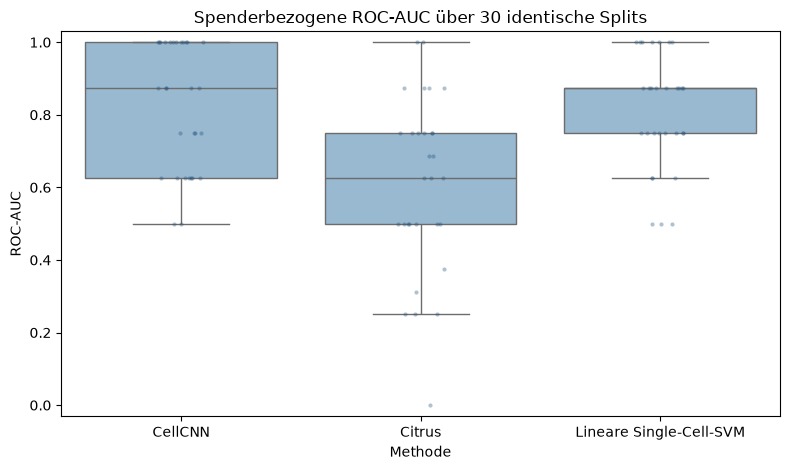

In [4]:
# Zweck: Verteilung aller Split-ROC-AUCs in einer berichtstauglichen Abbildung zeigen.
method_order = ["CellCNN", "Citrus", "Lineare Single-Cell-SVM"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.boxplot(
    data=split_metrics, x="method_label", y="roc_auc",
    order=method_order, color="#8FBBD9", showfliers=False, ax=ax,
)
sns.stripplot(
    data=split_metrics, x="method_label", y="roc_auc",
    order=method_order, color="#1F4E79", alpha=0.35, size=3, ax=ax,
)
ax.set(xlabel="Methode", ylabel="ROC-AUC", title=f"Spenderbezogene ROC-AUC über {EXPECTED_SPLIT_COUNT} identische Splits")
ax.set_ylim(-0.03, 1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task4_roc_auc_comparison.png", dpi=200)
plt.show()

## 5. Gepaarte ROC-AUC-Differenzen

Da alle Methoden dieselben Splits verwenden, werden die Differenzen pro Split direkt gepaart berechnet. Positive Werte sprechen für CellCNN.

,Vergleich,Median,Q1,Q3
0,CellCNN − Citrus,0.188,0.016,0.375
1,CellCNN − lineare SVM,0.000,0.000,0.125


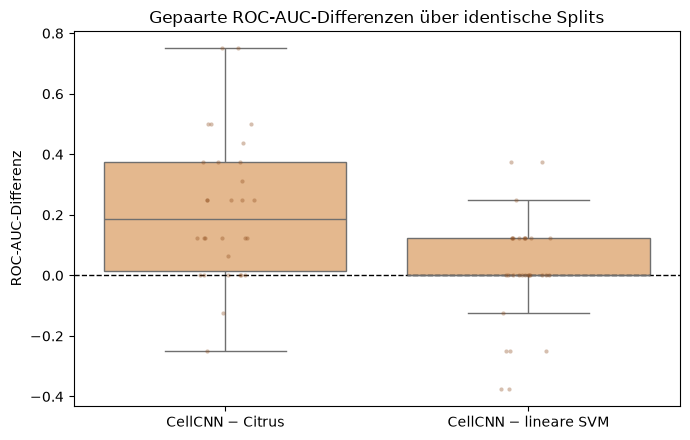

In [5]:
# Zweck: Methoden innerhalb desselben Splits paaren und so Split-Schwierigkeit herausrechnen.
roc_wide = split_metrics.pivot(index="split_id", columns="method_label", values="roc_auc")
paired_differences = pd.DataFrame(
    {
        "CellCNN − Citrus": roc_wide["CellCNN"] - roc_wide["Citrus"],
        "CellCNN − lineare SVM": (
            roc_wide["CellCNN"] - roc_wide["Lineare Single-Cell-SVM"]
        ),
    }
).reset_index()
paired_long = paired_differences.melt(
    id_vars="split_id", var_name="Vergleich", value_name="ROC-AUC-Differenz"
)
paired_summary = (
    paired_long.groupby("Vergleich")["ROC-AUC-Differenz"]
    .agg(Median="median", Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75))
    .reset_index()
)
paired_differences.to_csv(TABLES_DIR / "task4_paired_roc_auc_differences.csv", index=False)
paired_summary.to_csv(TABLES_DIR / "task4_paired_roc_auc_summary.csv", index=False)
display(paired_summary.round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(
    data=paired_long, x="Vergleich", y="ROC-AUC-Differenz",
    color="#F2B880", showfliers=False, ax=ax,
)
sns.stripplot(
    data=paired_long, x="Vergleich", y="ROC-AUC-Differenz",
    color="#8C4A1A", alpha=0.35, size=3, ax=ax,
)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set(title="Gepaarte ROC-AUC-Differenzen über identische Splits", xlabel="")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task4_paired_roc_auc_differences.png", dpi=200)
plt.show()

## 6. Zusätzlicher CellCNN–SVM-Vergleich über 100 Splits

Dieser Zweiervergleich nutzt alle vorhandenen 100 gemeinsamen Splits (0–99), also 600 Testvorhersagen je Methode. Er ergänzt den Dreiervergleich über 30 Splits. Kennzahlen mit unterschiedlicher Wiederholungszahl werden nicht als derselbe Vergleich dargestellt. Auch 100 Wiederholungen basieren weiterhin auf denselben 20 Spendern.


In [6]:
# Zweck: Vorhandene CellCNN-/SVM-Ergebnisse über alle 100 gemeinsamen Splits auswerten.
cellcnn_svm_metrics = (
    cellcnn_svm_predictions.groupby(["method_label", "split_id"])
    .apply(compute_metrics, include_groups=False)
    .reset_index()
)
assert cellcnn_svm_metrics.groupby("method_label")["split_id"].nunique().eq(100).all()
cellcnn_svm_summary = (
    cellcnn_svm_metrics.melt(
        id_vars=["method_label", "split_id"], value_vars=metric_columns,
        var_name="Metrik", value_name="Wert",
    )
    .groupby(["method_label", "Metrik"])["Wert"]
    .agg(Median="median", Q1=lambda x: x.quantile(0.25),
         Q3=lambda x: x.quantile(0.75), Mittelwert="mean", Standardabweichung="std")
    .reset_index().rename(columns={"method_label": "Methode"})
)
cellcnn_svm_metrics.to_csv(TABLES_DIR / "task4_cellcnn_svm_100_split_metrics.csv", index=False)
cellcnn_svm_summary.to_csv(TABLES_DIR / "task4_cellcnn_svm_100_metric_summary.csv", index=False)
print("CellCNN und SVM: 100 gemeinsame Splits, 600 Testvorhersagen je Methode")
display(cellcnn_svm_summary.round(3))

cellcnn_svm_roc = cellcnn_svm_metrics.pivot(
    index="split_id", columns="method_label", values="roc_auc"
)
cellcnn_svm_difference = cellcnn_svm_roc["CellCNN"] - cellcnn_svm_roc["Lineare Single-Cell-SVM"]
print("Gepaarte ROC-AUC-Differenz CellCNN − SVM über 100 Splits:")
display(cellcnn_svm_difference.describe().loc[["count", "mean", "25%", "50%", "75%"]].round(3))


CellCNN und SVM: 100 gemeinsame Splits, 600 Testvorhersagen je Methode


,Methode,Metrik,Median,Q1,Q3,Mittelwert,Standardabweichung
0,CellCNN,average_precision,0.833,0.700,1.000,0.804,0.180
1,CellCNN,balanced_accuracy,0.750,0.500,0.781,0.679,0.190
2,CellCNN,pr_auc,0.792,0.662,1.000,0.761,0.224
3,CellCNN,roc_auc,0.875,0.750,1.000,0.808,0.193
4,Lineare Single-Cell-SVM,average_precision,0.833,0.692,1.000,0.780,0.182
5,Lineare Single-Cell-SVM,balanced_accuracy,0.625,0.500,0.750,0.620,0.159
6,Lineare Single-Cell-SVM,pr_auc,0.792,0.655,1.000,0.731,0.228
7,Lineare Single-Cell-SVM,roc_auc,0.875,0.625,1.000,0.784,0.195


Gepaarte ROC-AUC-Differenz CellCNN − SVM über 100 Splits:


count    100.000
mean       0.024
25%        0.000
50%        0.000
75%        0.125
dtype: float64

## 7. Leistung, Interpretierbarkeit und Laufzeit

Die oben berechneten Tabellen zeigen die aktuelle Leistung und die gepaarten ROC-AUC-Differenzen. Aussagen aus dem früheren Citrus-Lauf mit 1.000 Zellen und 5 % Mindestclustergröße gelten nicht für den korrigierten Vergleich.

Die Balanced Accuracy hängt zusätzlich von der Schwellenwertwahl ab: CellCNN und Citrus verwenden 0,5, die SVM einen innerlich gelernten Youden-Schwellenwert. Die ROC-AUC bewertet dagegen die Rangfolge der Spender.

CellCNN liefert Markerfilter und Zellantworten, die SVM Markergewichte und Top-1-%-Zellscores. Citrus liefert hierarchische Cluster mit Häufigkeitskoeffizienten. Aufgabe 5 interpretiert dieselben 30 Splits mit den aktuellen Citrus-Clusterzentroiden. Die Ergebnisse stehen unter `task5_paper_*`; frühere `task5_*`-Dateien bleiben historisch.

CellCNN wurde auf einer GPU trainiert, SVM und Citrus verwenden die CPU. Unterschiedliche Hardware und Ausführungsbedingungen erlauben keinen fairen quantitativen Laufzeitvergleich aus diesen Läufen.


## 8. Qualitätscheck für Messtag und Instrument

Die Tabelle zeigt die Labelverteilung auf Spenderebene; beide CMV-Gruppen kommen
an jedem Messtag mit annähernd gleichen Anteilen vor. Innerhalb jedes
Trainingssplits wird ausschließlich aus Messtag bzw. Instrumentversion die
CMV+-Häufigkeit geschätzt und auf Testspender desselben Batches übertragen.
Dieser Kontrollscore ist keine vierte Hauptmethode.

Die niedrigen Kontroll-AUCs sind bei dieser kleinen, annähernd ausgeglichenen
Kohorte erklärbar: Landen überproportional viele positive Spender eines Batches
im Training, bleiben dort eher negative Spender für den komplementären Test.
Die Trainingshäufigkeit kann dann im Test in die Gegenrichtung weisen. Das ist
kein Beleg für vertauschte Labels. Ein direkter Batch-Label-Zusammenhang ist hier
nicht auffällig; technische Expressionsverschiebungen oder eine eingeschränkte
Übertragbarkeit auf neue Messtage werden dadurch nicht ausgeschlossen.
Instrumentversion und Messtag sind zudem gekoppelt und keine unabhängigen Kontrollen.


In [7]:
# Zweck: Testen, ob Messtag oder Instrument allein das Label auf neuen Spendern erklären.
data_root = PROJECT_ROOT / "NK_cell_dataset" / "NK_cell_dataset"
fcs_directory = data_root / "NK_cell_dataset" / GATE
metadata_records = []
for path in sorted(fcs_directory.glob("*.fcs")):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=r"FCS file .* reported incorrect data offset.*")
        sample = fk.Sample(str(path), ignore_offset_error=True)
    metadata_records.append(
        {
            "donor_id": path.stem.removesuffix("_alive"),
            "measurement_date": sample.metadata.get("date", ""),
            "instrument": sample.metadata.get("cyt", ""),
        }
    )
technical_metadata = pd.DataFrame(metadata_records)
assert len(technical_metadata) == 20 and technical_metadata["donor_id"].is_unique
assert technical_metadata[["measurement_date", "instrument"]].ne("").all().all()
split_with_metadata = donor_splits.merge(technical_metadata, on="donor_id", validate="many_to_one")
batch_records = []
for split_id, split in split_with_metadata.groupby("split_id"):
    train = split.loc[split["outer_partition"].eq("train")]
    test = split.loc[split["outer_partition"].eq("test")]
    for variable in ("measurement_date", "instrument"):
        # Batch-Raten werden ausschließlich im Training geschätzt und dann übertragen.
        rates = train.groupby(variable)["label"].mean()
        scores = test[variable].map(rates).fillna(train["label"].mean())
        batch_records.append(
            {
                "split_id": split_id,
                "technical_variable": variable,
                "roc_auc": roc_auc_score(test["label"], scores),
            }
        )
batch_control = pd.DataFrame(batch_records)
batch_control.to_csv(TABLES_DIR / "task4_batch_control.csv", index=False)
donor_metadata = technical_metadata.merge(
    donor_splits[["donor_id", "label"]].drop_duplicates(),
    on="donor_id", validate="one_to_one",
)
batch_label_counts = pd.crosstab(donor_metadata["measurement_date"], donor_metadata["label"])
batch_label_counts = batch_label_counts.rename(columns={0: "CMV−", 1: "CMV+"})
batch_label_counts.index.name = "Messtag"
batch_label_counts.columns.name = "CMV-Status"
display(batch_label_counts)
batch_label_counts.to_csv(TABLES_DIR / "task4_batch_label_counts.csv")
batch_summary = batch_control.groupby("technical_variable")["roc_auc"].describe()
display(batch_summary.round(3))
print(
    "Der ausschließlich aus Trainings-Metadaten gebildete Kontrollscore erreicht "
    f"mediane Test-ROC-AUC {batch_summary.loc['measurement_date', '50%']:.3f} "
    f"für den Messtag und {batch_summary.loc['instrument', '50%']:.3f} "
    "für die Instrumentversion. Dies schließt technische Einflüsse auf "
    "Markerexpression und Modellleistung nicht aus."
)

CMV-Status,CMV−,CMV+
Messtag,,
01-May-2012,3,3
08-May-2012,3,2
12-Jun-2012,5,4


,count,mean,std,min,25%,50%,75%,max
technical_variable,,,,,,,,
instrument,30.0,0.396,0.109,0.125,0.375,0.375,0.500,0.5
measurement_date,30.0,0.304,0.132,0.062,0.250,0.250,0.406,0.5


Der ausschließlich aus Trainings-Metadaten gebildete Kontrollscore erreicht mediane Test-ROC-AUC 0.250 für den Messtag und 0.375 für die Instrumentversion. Dies schließt technische Einflüsse auf Markerexpression und Modellleistung nicht aus.


## Einordnung

Die 30 Monte-Carlo-Wiederholungen basieren auf denselben 20 Spendern und sind keine unabhängigen Studien. Gegenüber den 100 Wiederholungen im Paper ist die Leistungsstreuung weniger stabil geschätzt. Median und Streuung beschreiben die Sensitivität gegenüber der konkreten Train-Test-Aufteilung. Inhaltliche Schlussfolgerungen müssen die kleine Zahl unabhängiger Spender ausdrücklich berücksichtigen.

Bei Citrus gelten nur glmnet-Koeffizienten mit `abs(coefficient) > 1e-10` als
wirksam. Diese Regel gilt einheitlich für Clusterzahlen und exportierte Profile. Die offizielle Citrus-Ausgabe kann formal nicht-null Koeffizienten in der Größenordnung `1e-15` liefern, obwohl daraus konstante Spendervorhersagen von 0,5 entstehen.